In [16]:
!pip install -q transformers torch scikit-learn pandas matplotlib

import os
os.environ["WANDB_DISABLED"] = "true"



In [17]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    DebertaV2TokenizerFast,
    DebertaV2ForSequenceClassification,
    Trainer,
    TrainingArguments
)



In [18]:
df = pd.read_csv("/content/drive/MyDrive/AI_vs_Human_Text_Dataset.csv")
df = df.dropna(subset=["text", "label"])
df["label"] = df["label"].astype(int)



In [19]:
texts = df["text"].astype(str).tolist()
labels = df["label"].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


In [20]:
tokenizer = DebertaV2TokenizerFast.from_pretrained(
    "microsoft/deberta-v3-base"
)

train_enc = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=256
)

val_enc = tokenizer(
    X_val,
    truncation=True,
    padding=True,
    max_length=256
)


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [21]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)



In [22]:
train_ds = TextDataset(train_enc, y_train)
val_ds   = TextDataset(val_enc, y_val)



In [23]:
model = DebertaV2ForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=2
)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [25]:
training_args = TrainingArguments(
    output_dir="./deberta_results",
    do_train=True,
    do_eval=True,
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./deberta_logs"
)


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()


Step,Training Loss
500,0.049200
1000,0.000200
1500,0.000100
2000,0.000000
2500,0.000000
3000,0.000000


TrainOutput(global_step=3000, training_loss=0.008258024911706647, metrics={'train_runtime': 1852.407, 'train_samples_per_second': 12.956, 'train_steps_per_second': 1.62, 'total_flos': 3157389287424000.0, 'train_loss': 0.008258024911706647, 'epoch': 3.0})

In [27]:
trainer.evaluate()


{'eval_loss': 9.748113370733336e-06,
 'eval_accuracy': 1.0,
 'eval_precision': 1.0,
 'eval_recall': 1.0,
 'eval_f1': 1.0,
 'eval_runtime': 41.9147,
 'eval_samples_per_second': 47.716,
 'eval_steps_per_second': 5.965,
 'epoch': 3.0}

In [28]:
preds = trainer.predict(val_ds)

y_true = preds.label_ids
y_pred = preds.predictions.argmax(axis=1)
y_prob = torch.softmax(torch.tensor(preds.predictions), dim=1).numpy()[:, 1]


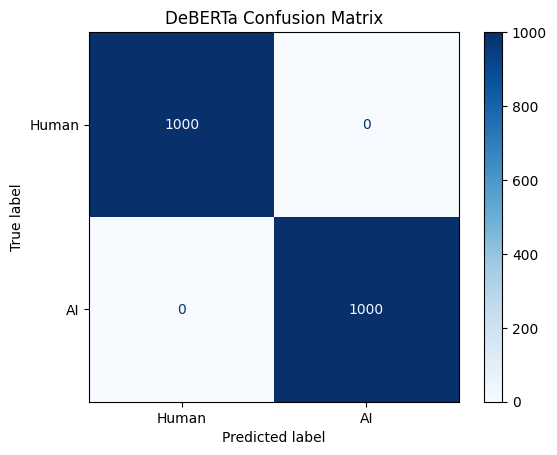

In [29]:
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"]).plot(cmap="Blues")
plt.title("DeBERTa Confusion Matrix")
plt.show()


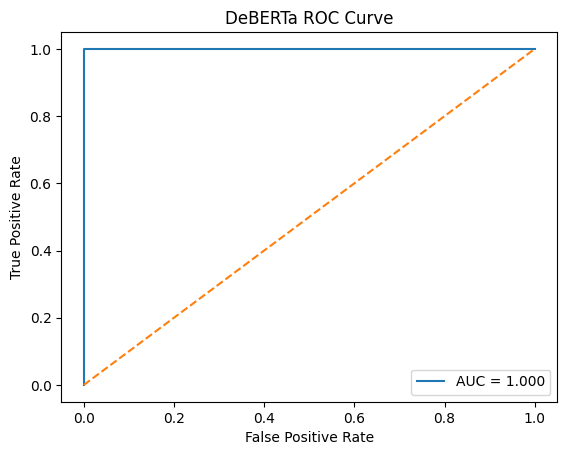

In [30]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DeBERTa ROC Curve")
plt.legend()
plt.show()
